# Choosing k - number of clusters

This notebook wll provide experiemnts for internal validation metric to choose the number of clusters k.

In [2]:
# Main packages 
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

# Clustering packages
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [3]:
# Load data
df = pl.scan_csv("/home/lanl/data/cyber1/auth.txt.gz",has_header=False,separator=",",
                 new_columns= ['time','src_user','dest_user','src_comp','dest_comp',
                               'auth_type','logon_type','auth_orientation','outcome'])

In [4]:
# Keep only human users
df = df.filter(pl.col("src_user").str.starts_with("U"))

We will start by fixing the aggregation level at 1 hour and the window size at 1 days. We will use 7 days of data to begin with, because of computational considerations, then will possibly extend to use large window sizes and more data. 

In [ ]:
# Time conversions
AGG_HOURS = 1
SECONDS_IN_DAY = 60 * 60 * 24
AGG_SECONDS = AGG_HOURS * 60 * 60 

### Tumbling Windows vs Sliding Windows

Justifications of using tumbling windows:
- Computationally cheaper
- Each window could be considered statistically independent
- Easier to evaluate, the metrics are easier to compare window T against window T + 1

Need to find explicit references for this.


In [6]:
# Features dataframe
features = (
    df
    .with_columns(
        bucket=pl.col("time") // AGG_SECONDS,
        theta= ((pl.col("time") % SECONDS_IN_DAY) / SECONDS_IN_DAY) * 2 * np.pi,
        is_failure=(pl.col("outcome") != "Success").cast(pl.Int8),
    )
    .group_by(["src_user", "bucket"])
    .agg(
        n_events=pl.len(),
        failure_ratio=pl.col("is_failure").mean(),
        n_distinct_dest=pl.col("dest_comp").n_unique(),
        n_distinct_src=pl.col("src_comp").n_unique(),
        C_bar=pl.col("theta").cos().mean(),
        S_bar=pl.col("theta").sin().mean(),
    ).with_columns(
    log_n_events=pl.col("n_events").log1p(),
    log_n_distinct_dest=pl.col("n_distinct_dest").log1p(),
    log_n_distinct_src=pl.col("n_distinct_src").log1p(),
)
    .collect()
)

In [8]:
# Extract relevant features
feature_cols = [
    "log_n_events",
    "failure_ratio",
    "log_n_distinct_dest",
    "log_n_distinct_src",
    "C_bar",
    "S_bar",
]

**Silhouette Score**

- used in sanchez paper + commonly used

In [9]:
# Day 1
day1_features = features.filter(pl.col("bucket").is_between(0, 23))
X = day1_features.select(feature_cols).to_numpy()

In [10]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

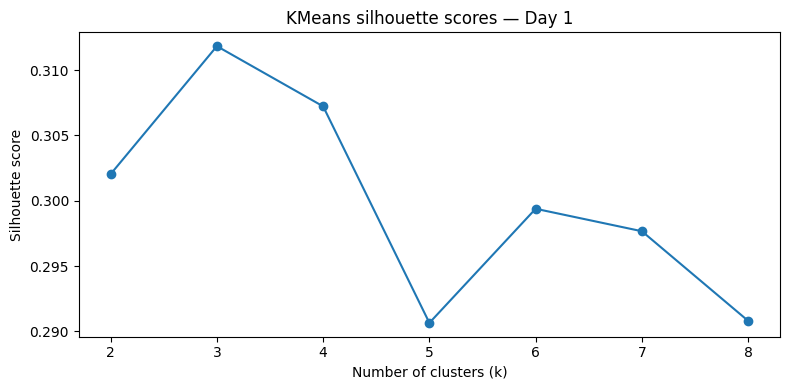

In [11]:
# KMeans sweep k=2 to 8
K_RANGE = range(2, 9)
silhouette_scores = {}

from joblib import Parallel, delayed

def fit_kmeans(k, X):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    score = silhouette_score(X, labels, random_state=42)
    return k, score

results = Parallel(n_jobs=-1)(delayed(fit_kmeans)(k, X_scaled) for k in K_RANGE)
silhouette_scores = dict(results)

# Plot
plt.figure(figsize=(8, 4))
plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("KMeans silhouette scores — Day 1")
plt.xticks(list(K_RANGE))
plt.tight_layout()
plt.show()

In [ ]:
# Find best k
best_k = max(silhouette_scores, key=silhouette_scores.get)
best_score = silhouette_scores[best_k]
print(f"Best k={best_k}  silhouette={best_score:.4f}")

# Refit on best k to get labels
best_km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
best_labels = best_km.fit_predict(X_scaled)

Best k=3  silhouette=0.3118


In [13]:
# Attach labels back to the dataframe
day1_features = day1_features.with_columns(
    pl.Series("cluster", best_labels)
)

# Save
day1_features.write_parquet("/home/ma/t/tr725/MSc-Project/03_working_notebooks/day1_clustered.parquet")

In [14]:
day1_features = pl.read_parquet("/home/ma/t/tr725/MSc-Project/03_working_notebooks/day1_clustered.parquet")

In [ ]:
day1_features.group_by("cluster").agg(pl.len().alias("n_members")).sort("cluster")

cluster,n_members
i32,u64
0,5031
1,53002
2,43395
